In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os
path = "/content/drive/MyDrive/FarmAI/"
print(os.listdir(path))

['archive (9).zip', 'disease_model.h5', 'disease_labels.json', 'irrigation_model.pkl']


In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/FarmAI/archive (9).zip'
extract_path = '/content/plantvillage'

# Verify if the file exists before attempting to extract
if not os.path.exists(zip_path):
    print(f"Error: The file '{zip_path}' does not exist. Please check the path and ensure the file is in your Google Drive.")
else:
    print("Extracting dataset... this may take 2-3 minutes")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

    print("Extraction complete!")

Extracting dataset... this may take 2-3 minutes
Extraction complete!


In [ ]:
# Find the correct folder path
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    if level < 2:
        indent = ' ' * 2 * level
        print(f'{indent}{os.path.basename(root)}/')

plantvillage/
  plantvillage dataset/


In [ ]:
import pathlib

# Update this path based on Cell 3 output
data_dir = pathlib.Path('/content/plantvillage/plantvillage dataset/color')

# Count classes
classes = sorted([d.name for d in data_dir.iterdir() if d.is_dir()])
print(f"Total classes: {len(classes)}")
print(f"\nFirst 10 classes:")
for c in classes[:10]:
    print(f"  {c}")

# Count total images
total = sum(1 for _ in data_dir.rglob('*.jpg'))
print(f"\nTotal images: {total}")

Total classes: 38

First 10 classes:
  Apple___Apple_scab
  Apple___Black_rot
  Apple___Cedar_apple_rust
  Apple___healthy
  Blueberry___healthy
  Cherry_(including_sour)___Powdery_mildew
  Cherry_(including_sour)___healthy
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
  Corn_(maize)___Common_rust_
  Corn_(maize)___Northern_Leaf_Blight

Total images: 1500


In [ ]:
import random
sample_classes = random.sample(classes, 8)

for cls in sample_classes:
    folder = data_dir / cls
    print(f"\nClass: {cls}")
    print("Exists:", folder.exists())

    if folder.exists():
        files = list(folder.glob('*'))
        print("Total files:", len(files))
        print("Sample files:", files[:3])


Class: Cherry_(including_sour)___Powdery_mildew
Exists: True
Total files: 1052
Sample files: [PosixPath('/content/plantvillage/plantvillage dataset/color/Cherry_(including_sour)___Powdery_mildew/30c6065a-983d-4bba-bce7-5ae0e9bce60c___FREC_Pwd.M 4676.JPG'), PosixPath('/content/plantvillage/plantvillage dataset/color/Cherry_(including_sour)___Powdery_mildew/3c51251b-482f-4753-adff-c0049bcb9a6a___FREC_Pwd.M 5118.JPG'), PosixPath('/content/plantvillage/plantvillage dataset/color/Cherry_(including_sour)___Powdery_mildew/f0af55b8-2e06-4881-ba70-1b1918473a95___FREC_Pwd.M 4731.JPG')]

Class: Tomato___Tomato_mosaic_virus
Exists: True
Total files: 373
Sample files: [PosixPath('/content/plantvillage/plantvillage dataset/color/Tomato___Tomato_mosaic_virus/5f45109b-365d-47f2-9921-07e576ac9a93___PSU_CG 2314.JPG'), PosixPath('/content/plantvillage/plantvillage dataset/color/Tomato___Tomato_mosaic_virus/6374877d-fcc6-4a2a-97de-e4d0c157ffae___PSU_CG 2068.JPG'), PosixPath('/content/plantvillage/plantvi

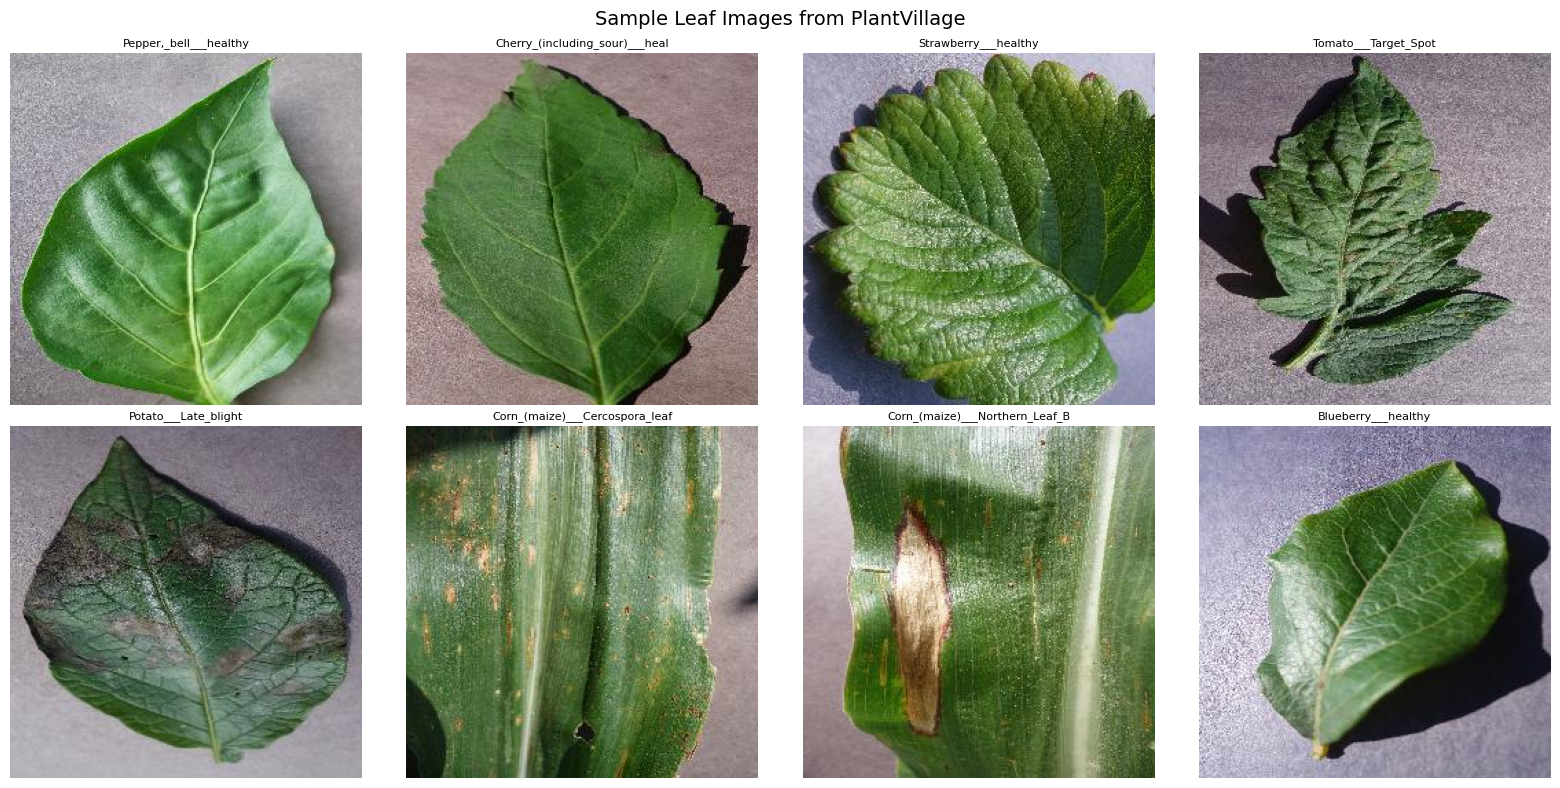

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

sample_classes = random.sample(classes, 8)
for ax, cls in zip(axes, sample_classes):
    images = list((data_dir / cls).glob('*.*'))
    img = mpimg.imread(str(random.choice(images)))
    ax.imshow(img)
    ax.set_title(cls[:30], fontsize=8)
    ax.axis('off')

plt.suptitle('Sample Leaf Images from PlantVillage', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: []


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
data_dir = '/content/plantvillage/plantvillage dataset/color'

# Augment training data to prevent overfitting
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print(f"\nTraining samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")
print(f"Number of classes: {len(train_generator.class_indices)}")

Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.

Training samples: 43456
Validation samples: 10849
Number of classes: 38


In [ ]:
import json

class_indices = train_generator.class_indices
class_labels = {v: k for k, v in class_indices.items()}

with open('disease_labels.json', 'w') as f:
    json.dump(class_labels, f)

print("Class labels saved!")
print(f"Sample labels: {list(class_labels.items())[:5]}")

Class labels saved!
Sample labels: [(0, 'Apple___Apple_scab'), (1, 'Apple___Black_rot'), (2, 'Apple___Cedar_apple_rust'), (3, 'Apple___healthy'), (4, 'Blueberry___healthy')]


BUILD THE MODEL


In [ ]:
# Load pretrained MobileNetV2 without top layer
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model layers first
base_model.trainable = False

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
output = Dense(len(class_labels), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(model.summary())
print(f"\nTotal layers: {len(model.layers)}")
print(f"Trainable layers: {len([l for l in model.layers if l.trainable])}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,623,718 (10.01 MB)

 Trainable params: 365,734 (1.40 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

None

Total layers: 160
Trainable layers: 6


In [ ]:
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2,
        verbose=1
    )
]

print("Phase 1: Training classification head only...")
history1 = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

Phase 1: Training classification head only...
Epoch 1/7
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1764s 1s/step - accuracy: 0.7557 - loss: 0.8242 - val_accuracy: 0.8850 - val_loss: 0.3434 - learning_rate: 0.0010
Epoch 2/7
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1820s 1s/step - accuracy: 0.8572 - loss: 0.4448 - val_accuracy: 0.9010 - val_loss: 0.2998 - learning_rate: 0.0010
Epoch 3/7
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1981s 1s/step - accuracy: 0.8759 - loss: 0.3827 - val_accuracy: 0.9124 - val_loss: 0.2652 - learning_rate: 0.0010
Epoch 4/7
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 2078s 2s/step - accuracy: 0.8871 - loss: 0.3479 - val_accuracy: 0.9284 - val_loss: 0.2191 - learning_rate: 0.0010
Epoch 5/7
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 2413s 2s/step - accuracy: 0.8936 - loss: 0.3325 - val_accuracy: 0.9287 - val_loss: 0.2099 - learning_rate: 0.0010
Epoch 6/7
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1776s 1s/step - accuracy: 0.9025 - loss: 0.3034 - val_accuracy: 0.9266 - val_loss: 0.2185 - learning_rate: 0.0010
Epoch 7/7
1358/1358 ━━━━

In [ ]:
 # Unfreeze last 30 layers of base model
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Phase 2: Fine-tuning top layers...")
history2 = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)


Phase 2: Fine-tuning top layers...
Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 2274s 2s/step - accuracy: 0.8249 - loss: 0.6201 - val_accuracy: 0.9276 - val_loss: 0.2094 - learning_rate: 1.0000e-05
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 2141s 2s/step - accuracy: 0.8943 - loss: 0.3348 - val_accuracy: 0.9405 - val_loss: 0.1814 - learning_rate: 1.0000e-05
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 2199s 2s/step - accuracy: 0.9140 - loss: 0.2723 - val_accuracy: 0.9457 - val_loss: 0.1623 - learning_rate: 1.0000e-05
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 2233s 2s/step - accuracy: 0.9263 - loss: 0.2355 - val_accuracy: 0.9545 - val_loss: 0.1320 - learning_rate: 1.0000e-05
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 2245s 2s/step - accuracy: 0.9344 - loss: 0.2063 - val_accuracy: 0.9587 - val_loss: 0.1264 - learning_rate: 1.0000e-05
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 2202s 2s/step - accuracy: 0.9406 - loss: 0.1887 - val_accuracy: 0.9617 - val_loss: 0.1137 - learning_rate: 1.0000e-05
Epoch


 Final Validation Accuracy: 96.80%
 Final Validation Loss: 0.0983


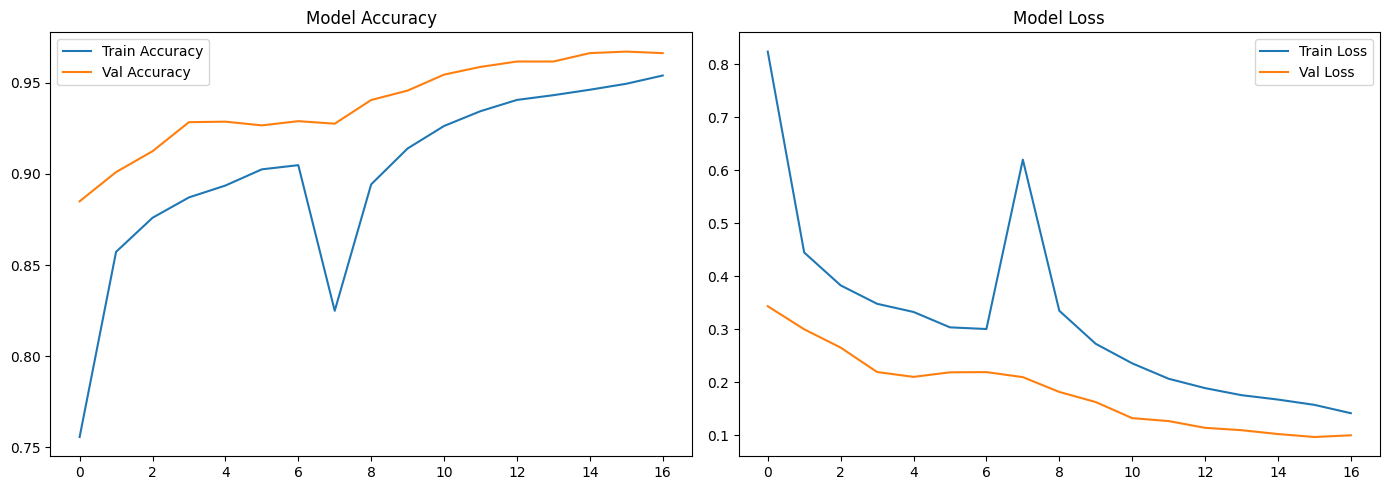

In [ ]:
# Final accuracy
val_loss, val_acc = model.evaluate(val_generator, verbose=0)
print(f"\n Final Validation Accuracy: {val_acc * 100:.2f}%")
print(f" Final Validation Loss: {val_loss:.4f}")

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Combine histories
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc_hist = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss = history1.history['loss'] + history2.history['loss']
val_loss_hist = history1.history['val_loss'] + history2.history['val_loss']

axes[0].plot(acc, label='Train Accuracy')
axes[0].plot(val_acc_hist, label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].legend()

axes[1].plot(loss, label='Train Loss')
axes[1].plot(val_loss_hist, label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Save model
model.save('disease_model.h5')
print(" Model saved as disease_model.h5")

# Verify file size
import os
size = os.path.getsize('disease_model.keras') / (1024 * 1024)
print(f"Model size: {size:.2f} MB")

 Model saved as disease_model.h5
Model size: 25.03 MB


In [ ]:
import shutil

# Save to Drive so you don't lose it if Colab disconnects
shutil.copy('disease_model.h5', '/content/drive/MyDrive/FarmAI/disease_model.h5')
shutil.copy('disease_labels.json', '/content/drive/MyDrive/FarmAI/disease_labels.json')
print("Model backed up to Google Drive!")

Model backed up to Google Drive!


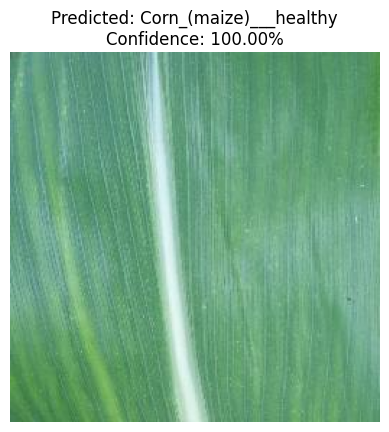

True: Corn_(maize)___healthy
Predicted: Corn_(maize)___healthy
Confidence: 100.00%
Correct: true



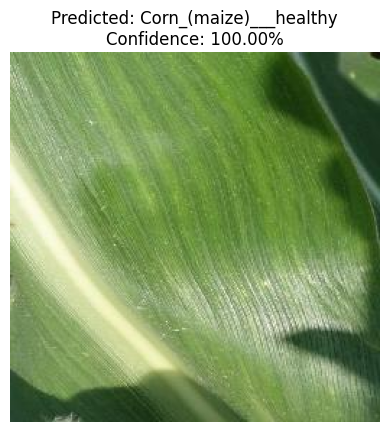

True: Corn_(maize)___healthy
Predicted: Corn_(maize)___healthy
Confidence: 100.00%
Correct: true



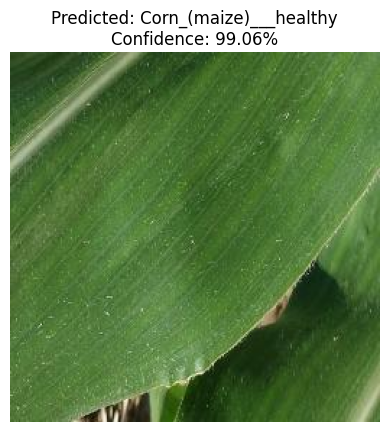

True: Corn_(maize)___healthy
Predicted: Corn_(maize)___healthy
Confidence: 99.06%
Correct: true



In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import random

def test_prediction(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    predictions = model.predict(img_array, verbose=0)
    predicted_class = class_labels[np.argmax(predictions)]
    confidence = float(predictions.max())

    plt.imshow(image.load_img(img_path))
    plt.title(f"Predicted: {predicted_class}\nConfidence: {confidence:.2%}")
    plt.axis('off')
    plt.show()

    return predicted_class, confidence

# Test on 3 random validation images
data_dir_path = '/content/plantvillage/plantvillage dataset/color'
all_images = list(pathlib.Path(data_dir_path).rglob('*.jpg'))
sample_images = random.sample(all_images, 3)

for img_path in sample_images:
    true_label = img_path.parent.name
    predicted, conf = test_prediction(str(img_path))
    print(f"True: {true_label}")
    print(f"Predicted: {predicted}")
    print(f"Confidence: {conf:.2%}")
    print(f"Correct: {'true' if true_label == predicted else 'false'}\n")

In [ ]:
from google.colab import files

print("Downloading disease_model.h5 ...")
files.download('disease_model.h5')

print("Downloading disease_labels.json ...")
files.download('disease_labels.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>